In [12]:
import dreams_python
from dreams_python import emulation

In [3]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

# Train NeHOD Normalizing Flows Emulator

In this tutorial, we'll walk through how to load in and train a normalizing flows emulator from NeHOD (see Nguyen et al. 2026; https://ui.adsabs.harvard.edu/abs/2026ApJ...997..336N/abstract)

In this example, I already have some data saved in an HDF5 file that contains:

- `halo_mass` 
- `stellar_mass`
- `bh_mass`
- `gas_mass`
- `sizes`
- `gas_metallicity`
- `sfrs`

all loaded from the DREAMS mass varied suite (Torrey et al. In Preparation, Garcia et al. In Preparation)

## Load in data

In [6]:
data_file = '/home/aku7cf/DREAMS/mass_varied/calibration/data/sim_data.hdf5'

## load in simulation parameters 
mvs = dreams_python.DREAMS('/standard/DREAMS',suite='varied_mass',DM_type='CDM',sobol_number=6)
params, header = mvs.read_param_file('TNG_SB6.txt')

In [7]:
## load in (and clean) my data
with h5py.File(data_file,'r') as f:
    halo_mass    = np.log10(f['HaloMass'][...]+1e5)
    stellar_mass = np.log10(f['StellarMass'][...]+1e3)
    bh_mass      = np.log10(f['BHMass'][...]+1e3)
    gas_mass     = np.log10(f['GasMass'][...]+1e3)
    sizes        = np.log10(f['Size'][...]+1e-4)
    gas_metals   = f['GasMetallicity'][...]
    sfrs         = np.log10(f['SFRs'][...]+1e-4)

_labels_raw = np.column_stack([
    halo_mass, stellar_mass, bh_mass, gas_mass, sizes, gas_metals, sfrs
])
_finite_mask = np.all(np.isfinite(_labels_raw), axis=1)
n_bad = (~_finite_mask).sum()
if n_bad > 0:
    print(f"Dropping {n_bad}/{len(_finite_mask)} simulations with NaN/inf values.")

halo_mass    = halo_mass[_finite_mask]
stellar_mass = stellar_mass[_finite_mask]
bh_mass      = bh_mass[_finite_mask]
gas_mass     = gas_mass[_finite_mask]
sizes        = sizes[_finite_mask]
gas_metals   = gas_metals[_finite_mask]
sfrs         = sfrs[_finite_mask]
params       = params[_finite_mask]  ## keep params in sync!!

features = np.array([
    params[:, 0],
    params[:, 1],
    params[:, 2],
    np.log10(params[:, 3]), ## sn1, sn2, and AGN are log spaced
    np.log10(params[:, 4]),
    np.log10(params[:, 5])
]).T
labels = np.column_stack([
    halo_mass   ,
    stellar_mass,
    bh_mass     ,
    gas_mass    ,
    sizes       ,
    gas_metals  ,
    sfrs        
])

Dropping 396/1024 simulations with NaN/inf values.


## Train the emulator

This should be pretty straightforward... you can pass in your `features` (i.e., the inputs to your model) and your `labels` (i.e., the outputs you want to predict) into the `dreams_python.emulator` constructor. Note that this *should* work for an aribitrary number of features and/or labels.

You'll also want to name your emulator (I'm calling mine `"my_test"`). 

The training will create a new directory called `emulator/` which should hold all the data and training checkpoints.

In [13]:
## feed in simulation parameters (features) and data (labels) 
##   name your emulator (here it is "my_test")
##   point to your data directory (in my case I have it saved in a direct)
flow1 = emulation.emulator(features, labels, 'my_test')

## train the model (takes some time)
flow1.train_flow()

## at any point after training you can load in the model to mess around with it yourself
##    NOTE: this is *not* required for the built in functionality below
model = flow1.load_trained_flow()

[rank: 0] Seed set to 1234


Creating Directory emulator/ ...
Creating Directory emulator/flows/ ...
Creating Directory emulator/flows/my_test ...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1539: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/Context.cpp:80.)
  return _C._get_float32_matmul_precision()
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type       | Params | Mode 
-------------------------------------------------------
0 | lin_proj_layers | Sequential | 4.9 K  | train
1 | flow            | NSF    

SystemExit: 1

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## Check to see how we did

Once the model is trained, you'll be able to access the information for the loss function using `flow.loss_data()` which will tell you about the training and validation loss (note that a "test" set is [probably] unnecessary here!)

Note that the checkpointing means that there are effective "early stopping" conditions. Your predictions won't necessarily be from the last epoch, rather they'll be from the last saved checkpoint (which occurs when the validation loss decreases). As such, the final emulator will be the one that has the minimum *validation* loss

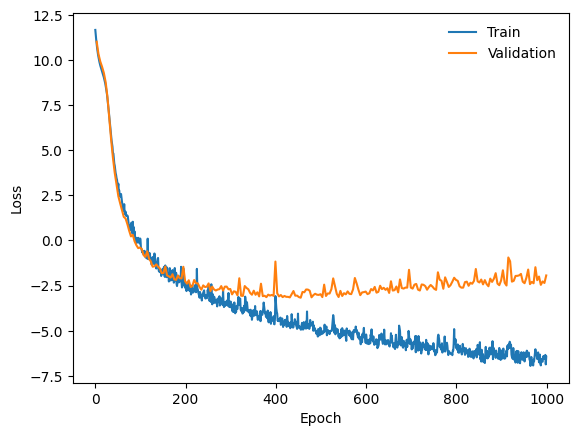

In [6]:
## Make plot of loss function as a function of epoch (noting that this has effective early stopping)
(train_loss, train_epoch), (valid_loss, valid_epoch) = flow1.loss_data()

fig = plt.figure()
plt.plot(train_epoch, train_loss, label='Train')
plt.plot(valid_epoch, valid_loss, label='Validation')
plt.legend(frameon=False)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Making Predictions

Once your emulator is trained and the loss function looks reasonable, you are free to make predictions using `flow.make_prediction`, which takes in a `context` variable, which is just the features you want to use to predict.

In this example, we'll do a prediction of 100,000 parameters sampled around the full suite of DREAMS parameters.

In [13]:
halo_mass_min, halo_mass_max = 9, 13
omega_m_min, omega_m_max     = params[:, 1].min(), params[:, 1].max()
sigma_8_min, sigma_8_max     = params[:, 2].min(), params[:, 2].max()
sn1_min,     sn1_max         = np.log10(params[:, 3].min()), np.log10(params[:, 3].max())
sn2_min,     sn2_max         = np.log10(params[:, 4].min()), np.log10(params[:, 4].max())
agn1_min,    agn1_max        = np.log10(params[:, 5].min()), np.log10(params[:, 5].max())

n_samples = 100_000
context = np.column_stack([
    np.random.uniform(halo_mass_min, halo_mass_max, size=(n_samples)),
    np.random.uniform(omega_m_min, omega_m_max, size=(n_samples)),
    np.random.uniform(sigma_8_min, sigma_8_max, size=(n_samples)),
    np.random.uniform(sn1_min, sn1_max, size=(n_samples)),
    np.random.uniform(sn2_min, sn2_max, size=(n_samples)),
    np.random.uniform(agn1_min, agn1_max, size=(n_samples)),
])

emulated_data = flow1.make_prediction(context) ## loads model and makes prediction based on your context

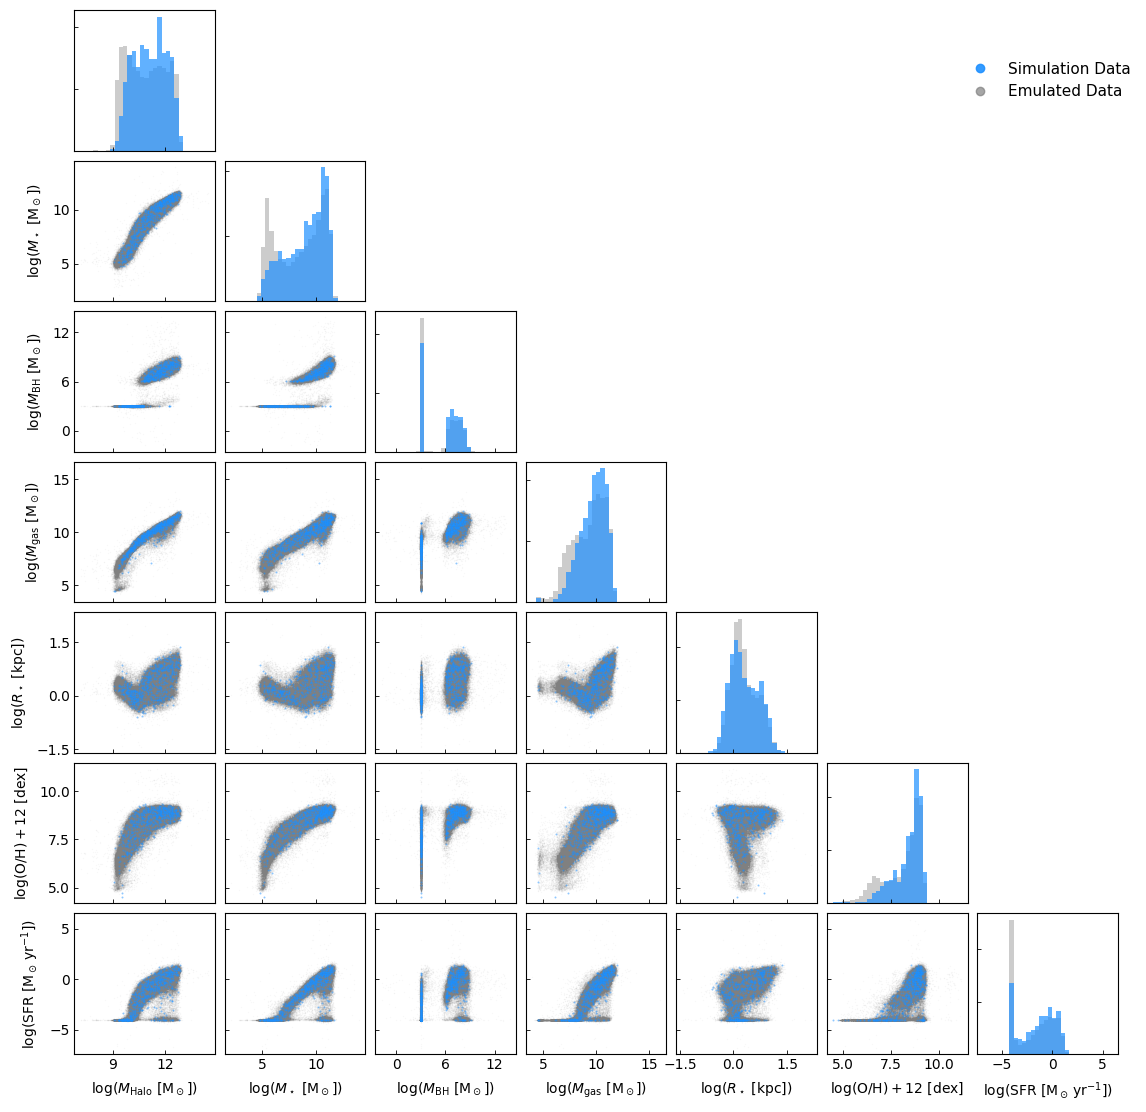

In [14]:
corner_labels = [
    r'$\log(M_{\rm Halo}~[{\rm M}_\odot])$',
    r'$\log(M_\star~[{\rm M}_\odot])$',
    r'$\log(M_{\rm BH}~[{\rm M}_\odot])$',
    r'$\log(M_{\rm gas}~[{\rm M}_\odot])$',
    r'$\log(R_\star~[{\rm kpc}])$',
    r'$\log({\rm O/H})+12~[{\rm dex}]$',
    r'$\log({\rm SFR}~[{\rm M}_\odot\,{\rm yr}^{-1}])$',
]

ndim = labels.shape[1]

RAW_SCAT_COLOR  = "dodgerblue"
RAW_HIST_COLOR  = "dodgerblue"

EMU_SCAT_COLOR  = "grey"
EMU_HIST_COLOR  = "grey"

ALPHA_SCAT_RAW  = 0.5
ALPHA_SCAT_EMU  = 0.05
N_BINS          = 30    

import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(12, 12))
gs  = gridspec.GridSpec(
    ndim, ndim, figure=fig,
    hspace=0.07, wspace=0.07,
    left=0.10, right=0.97, top=0.97, bottom=0.10,
)

axes = np.empty((ndim, ndim), dtype=object)

for row in range(ndim):
    for col in range(ndim):
        if col > row:
            continue

        sharex = axes[row - 1, col] if row > 0 and axes[row - 1, col] is not None else None
        sharey = axes[row, col - 1] if (col > 0 and row != col and axes[row, col - 1] is not None) else None

        ax = fig.add_subplot(gs[row, col], sharex=sharex, sharey=sharey)
        axes[row, col] = ax

        x_raw = labels[:, col]
        y_raw = labels[:, row]
        x_emu = emulated_data[:, col]
        y_emu = emulated_data[:, row]

        if row == col:
            x_raw_fin = x_raw[np.isfinite(x_raw)]
            x_emu_fin = x_emu[np.isfinite(x_emu)]

            # Shared bin edges so histograms are directly comparable
            all_vals = np.concatenate([x_raw_fin, x_emu_fin])
            bins = np.linspace(np.nanmin(all_vals), np.nanmax(all_vals), N_BINS + 1)

            ax.hist(x_emu_fin, bins=bins, color=EMU_HIST_COLOR, alpha=0.4,
                    linewidth=0, density=True, label='Emulated')
            ax.hist(x_raw_fin, bins=bins, color=RAW_HIST_COLOR, alpha=0.7,
                    linewidth=0, density=True, label='Simulated')
            ax.set_yticks([])
            ax.set_yticklabels([])
        else:
            # Emulated — drawn first so raw sits on top
            mask_emu = np.isfinite(x_emu) & np.isfinite(y_emu)
            x_emu_fin, y_emu_fin = x_emu[mask_emu], y_emu[mask_emu]
            ax.scatter(x_emu_fin, y_emu_fin, s=1, color=EMU_SCAT_COLOR,
                       alpha=ALPHA_SCAT_EMU, linewidths=0, rasterized=True)

            # Raw simulations — drawn on top
            mask_raw = np.isfinite(x_raw) & np.isfinite(y_raw)
            x_raw_fin, y_raw_fin = x_raw[mask_raw], y_raw[mask_raw]
            ax.scatter(x_raw_fin, y_raw_fin, s=2, color=RAW_SCAT_COLOR,
                       alpha=ALPHA_SCAT_RAW, linewidths=0, rasterized=True)

        if row == ndim - 1:
            ax.set_xlabel(corner_labels[col], labelpad=6)
        else:
            plt.setp(ax.get_xticklabels(), visible=False)

        if col == 0 and row != 0:
            ax.set_ylabel(corner_labels[row], labelpad=6)
        else:
            plt.setp(ax.get_yticklabels(), visible=False)

        ax.tick_params(axis="both", which="both", direction="in",
                       length=3, width=0.6, pad=3)
        ax.xaxis.set_major_locator(plt.MaxNLocator(3, prune="both"))
        ax.yaxis.set_major_locator(plt.MaxNLocator(3, prune="both"))

legend_ax = fig.add_subplot(gs[0, ndim - 1])
legend_ax.axis('off')
legend_ax.plot([], [], color=RAW_SCAT_COLOR, lw=0, marker='o',
               markersize=6, label='Simulation Data', alpha=0.9)
legend_ax.plot([], [], color=EMU_SCAT_COLOR, lw=0, marker='o',
               markersize=6, label='Emulated Data', alpha=0.7)
legend_ax.legend(frameon=False, loc='center', fontsize=11)

plt.show()

As we can see our model does reasonably well (hopefully this is true of your data, too!). There are ways that we can improve the model, but we'll save that for the next tutorial...